## Data loading and initial analysis

### Subtask:
Load the data and perform initial exploratory data analysis (EDA) to understand the dataset's structure, identify missing values, and visualize key distributions and relationships between features.


Contents of the 'insurance_data' directory:
Found CSV file at: insurance_data/Data/datasets_13720_18513_insurance(1).csv
First 5 rows of the DataFrame:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

Descriptive Statistics:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010



Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


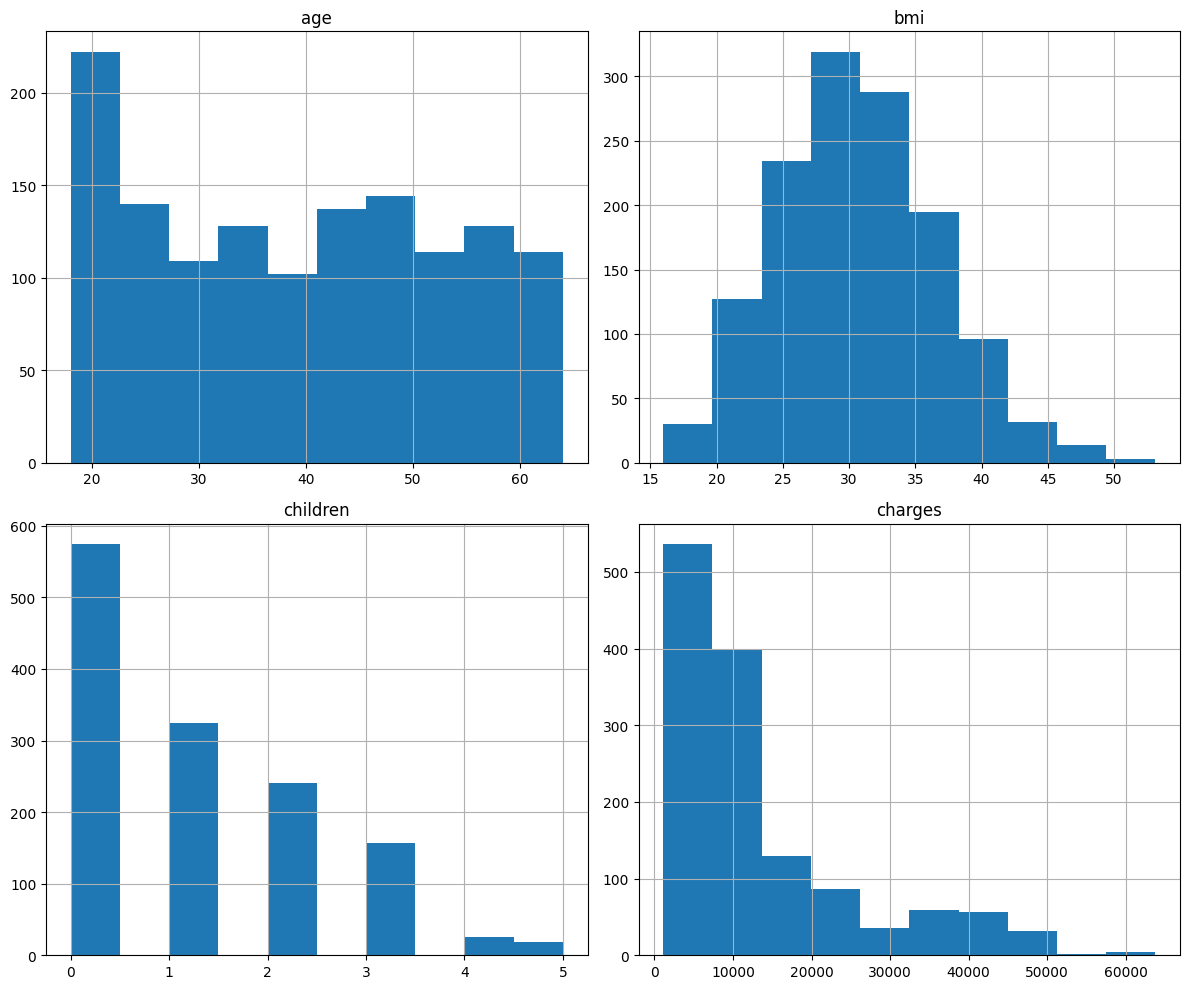

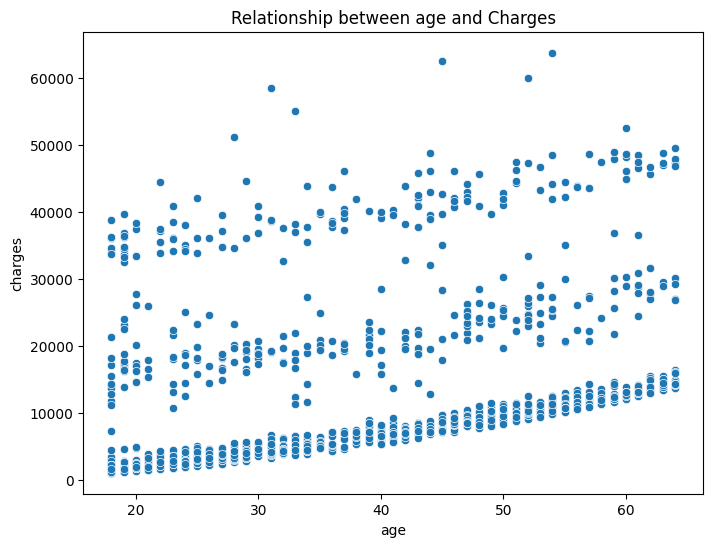

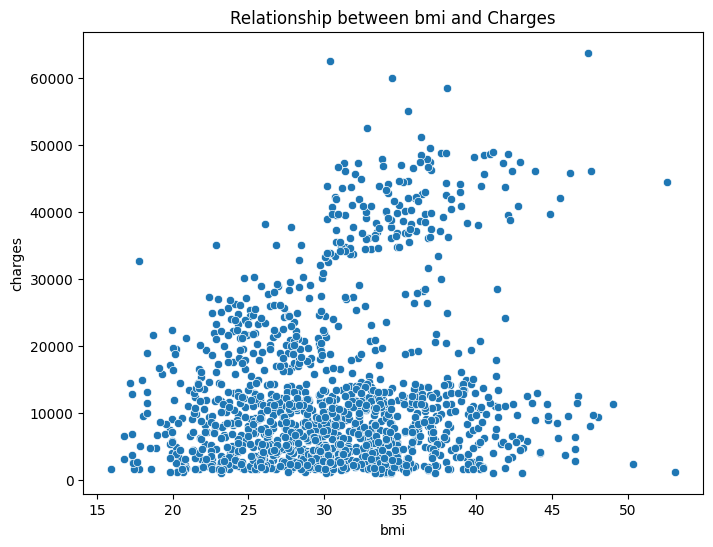

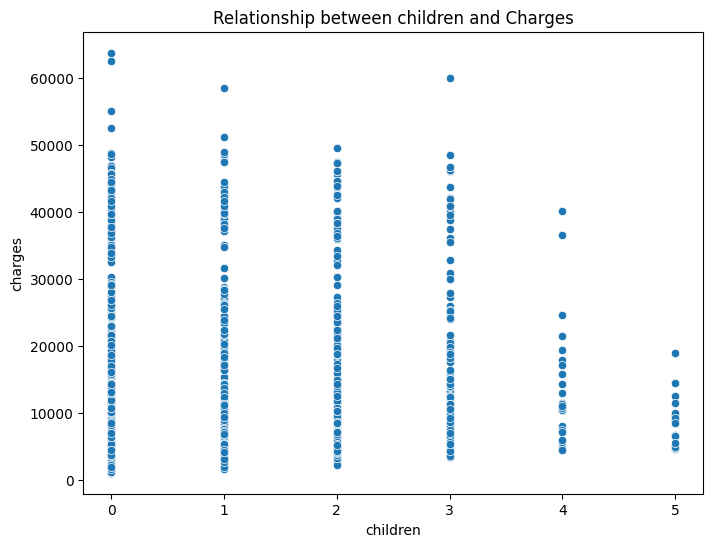

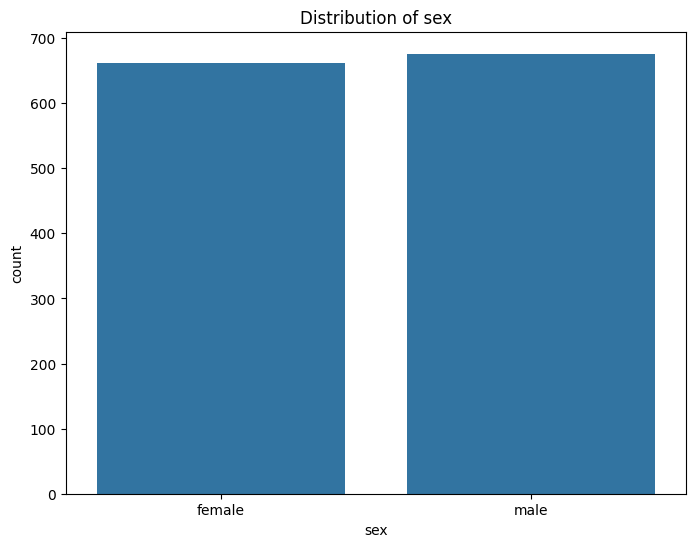

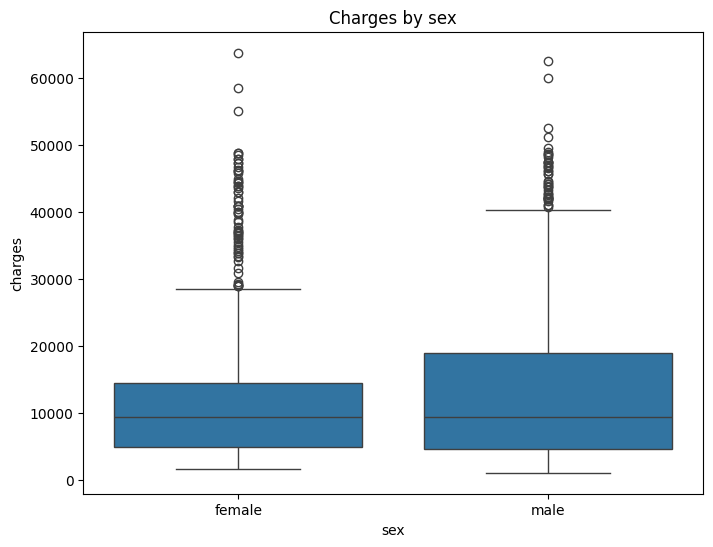

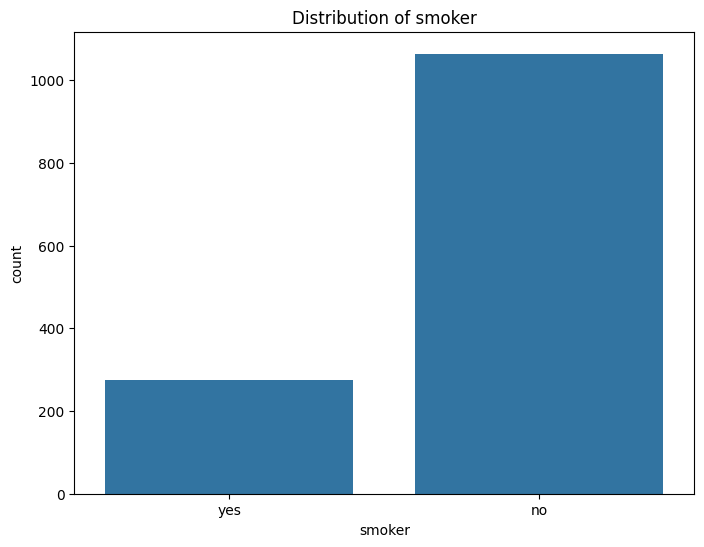

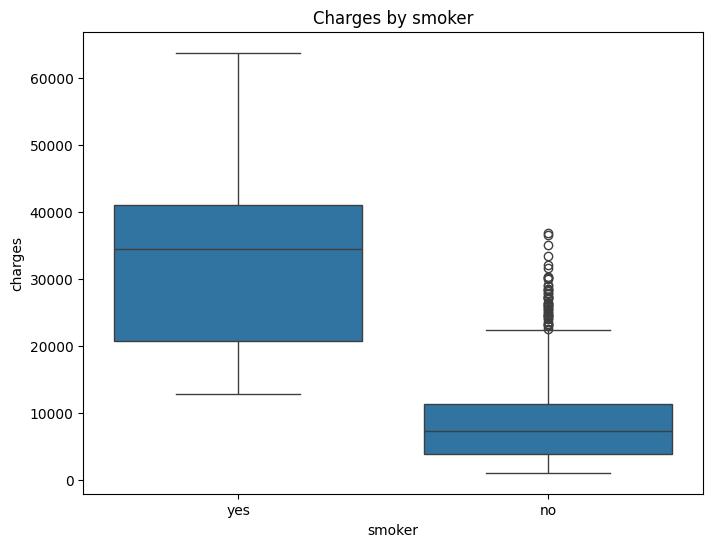

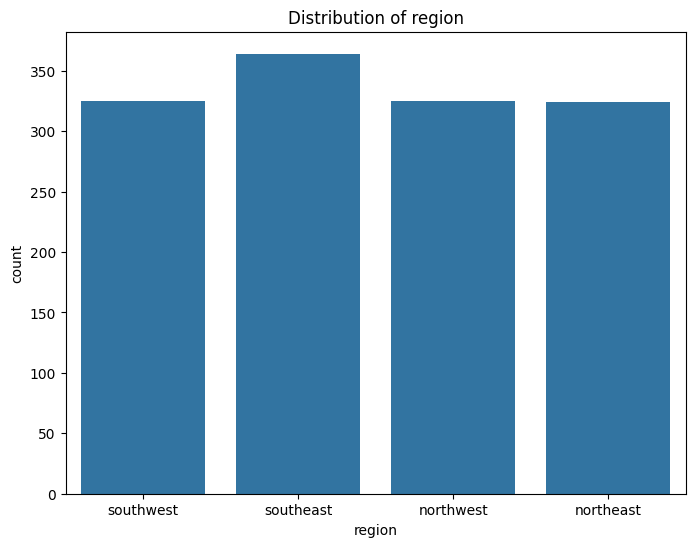

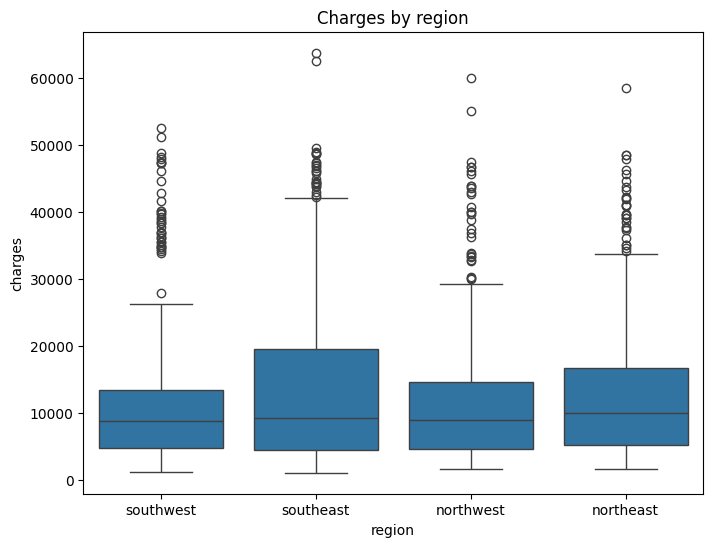

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# List the contents of the 'insurance_data' directory
# Assuming the zip was extracted to the current directory and contains 'insurance_data'
extracted_dir_path = 'insurance_data'
if not os.path.exists(extracted_dir_path):
    # If not found directly, let's try listing contents of the current directory to see where it was extracted
    print(f"'{extracted_dir_path}' not found. Listing contents of the current directory:")
    print(os.listdir('.'))
    raise FileNotFoundError(f"The directory '{extracted_dir_path}' was not found. Please ensure the zip file was extracted correctly.")


print(f"Contents of the '{extracted_dir_path}' directory:")
# Walk through the directory to find the CSV file
csv_file_path = None
for root, dirs, files in os.walk(extracted_dir_path):
    for file in files:
        if file.endswith('.csv'):
            csv_file_path = os.path.join(root, file)
            print(f"Found CSV file at: {csv_file_path}")
            break # Assuming there's only one primary CSV file
    if csv_file_path:
        break # Stop searching once a CSV is found

if not csv_file_path:
    raise FileNotFoundError(f"No CSV file found within the '{extracted_dir_path}' directory structure.")


# Load the data into a pandas DataFrame
df = pd.read_csv(csv_file_path)

# Display the first few rows
print("First 5 rows of the DataFrame:")
display(df.head())

# Get summary information
print("\nDataFrame Info:")
df.info()

# Get descriptive statistics
print("\nDescriptive Statistics:")
display(df.describe())

# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# Visualize distributions of numerical features
df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

# Visualize relationships between numerical features and 'charges'
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
numerical_cols = numerical_cols.drop('charges', errors='ignore') # Exclude 'charges' from features for scatter plots

for col in numerical_cols:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=col, y='charges', data=df)
    plt.title(f'Relationship between {col} and Charges')
    plt.show()

# Visualize distributions and relationships for categorical features
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    plt.figure(figsize=(8, 6))
    sns.countplot(x=col, data=df)
    plt.title(f'Distribution of {col}')
    plt.show()

    plt.figure(figsize=(8, 6))
    sns.boxplot(x=col, y='charges', data=df)
    plt.title(f'Charges by {col}')
    plt.show()

## Data preprocessing

### Subtask:
Handle categorical features by encoding them into numerical representations suitable for machine learning models. Address any missing values if necessary.


In [2]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=False)

# Display the head of the resulting DataFrame
display(df_encoded.head())

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,False,True,False,False


## Feature engineering

### Subtask:
Create new features or transform existing ones if needed to potentially improve model performance.


In [3]:
import numpy as np

# 1. Create interaction term between bmi and smoker (using the encoded smoker_yes column)
df_encoded['bmi_smoker_interaction'] = df_encoded['bmi'] * df_encoded['smoker_yes']

# 2. Transform skewed numerical feature 'charges' using log transformation
# Check skewness of 'charges'
print(f"Skewness of 'charges': {df_encoded['charges'].skew()}")
# Apply log transformation to 'charges'
df_encoded['charges_log'] = np.log1p(df_encoded['charges']) # Using log1p to handle potential zero values if any

# Check skewness after transformation
print(f"Skewness of 'charges_log' after transformation: {df_encoded['charges_log'].skew()}")

# 3. Consider polynomial features (e.g., age squared)
# Based on scatter plots in EDA, the relationship between age and charges seemed somewhat non-linear.
# Let's add age squared as a polynomial feature.
df_encoded['age_squared'] = df_encoded['age']**2

# 4. Display the head of the DataFrame with the new features
print("\nDataFrame with new features:")
display(df_encoded.head())

Skewness of 'charges': 1.5158796580240388
Skewness of 'charges_log' after transformation: -0.08981728740026822

DataFrame with new features:


,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest,bmi_smoker_interaction,charges_log,age_squared
0,19,27.900,0,16884.92400,True,False,False,True,False,False,False,True,27.9,9.734236,361
1,18,33.770,1,1725.55230,False,True,True,False,False,False,True,False,0.0,7.453882,324
2,28,33.000,3,4449.46200,False,True,True,False,False,False,True,False,0.0,8.400763,784
3,33,22.705,0,21984.47061,False,True,True,False,False,True,False,False,0.0,9.998137,1089
4,32,28.880,0,3866.85520,False,True,True,False,False,True,False,False,0.0,8.260455,1024


## Model selection

### Subtask:
Choose several appropriate machine learning models for regression to predict insurance charges.


In [4]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
import lightgbm as lgb
import xgboost as xgb

# Justifying the choice of models:
# 1. Linear Regression: A simple baseline model, good for understanding linear relationships. Fast to train.
# 2. Ridge: Linear model with L2 regularization. Helps prevent overfitting by shrinking coefficients, useful if features are correlated.
# 3. Lasso: Linear model with L1 regularization. Can perform feature selection by setting some coefficients to zero. Useful if many features are irrelevant.
# 4. Elastic Net: Combines L1 and L2 regularization. Good when there are groups of correlated features.
# 5. Decision Tree Regressor: Non-linear model. Can capture complex relationships but prone to overfitting. Easy to interpret (though less so for deep trees).
# 6. Random Forest Regressor: Ensemble of Decision Trees. Reduces overfitting and improves robustness compared to a single tree. Generally performs well.
# 7. Gradient Boosting Regressor (LightGBM, XGBoost): Powerful ensemble methods that build trees sequentially, correcting errors of previous trees. Often achieve state-of-the-art performance. Handle non-linearities and interactions well. LightGBM is known for speed and efficiency, XGBoost for performance and features.
# 8. Support Vector Regressor (SVR): Can capture linear and non-linear relationships using kernels. Performance can be sensitive to hyperparameter tuning and scales poorly with large datasets (though 1338 rows is manageable).

print("Selected regression models for the next step (Model Training).")

Selected regression models for the next step (Model Training).


## Model training

### Subtask:
Train the selected regression models on the prepared data.


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
import lightgbm as lgb
import xgboost as xgb

# 1. Define the feature matrix X and the target vector y
# We will predict the log-transformed charges as it was less skewed
X = df_encoded.drop(['charges', 'charges_log'], axis=1)
y = df_encoded['charges_log']

# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets.")
print(f"Training set shape: X_train - {X_train.shape}, y_train - {y_train.shape}")
print(f"Testing set shape: X_test - {X_test.shape}, y_test - {y_test.shape}")

# 3. Initialize each of the selected regression models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(random_state=42), # Added random_state for reproducibility where applicable
    "Lasso": Lasso(random_state=42),
    "Elastic Net": ElasticNet(random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting (LightGBM)": lgb.LGBMRegressor(random_state=42),
    "Gradient Boosting (XGBoost)": xgb.XGBRegressor(random_state=42),
    "SVR": SVR() # SVR does not have random_state
}

print("\nRegression models initialized.")

# 4. Train each model on the training data and 5. Store the trained models
trained_models = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"{name} trained.")

print("\nAll selected models have been trained.")

Data split into training and testing sets.
Training set shape: X_train - (1070, 13), y_train - (1070,)
Testing set shape: X_test - (268, 13), y_test - (268,)

Regression models initialized.
Training Linear Regression...
Linear Regression trained.
Training Ridge...
Ridge trained.
Training Lasso...
Lasso trained.
Training Elastic Net...
Elastic Net trained.
Training Decision Tree...
Decision Tree trained.
Training Random Forest...
Random Forest trained.
Training Gradient Boosting (LightGBM)...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000185 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 443
[LightGBM] [Info] Number of data points in the train set: 1070, number of used features: 13
[LightGBM] [Info] Start training from score 9.113489
Gradient Boosting (LightGBM) trained.
Training Gradient Boosting (XGBoost)...
Gradient Boosting (XG

## Model evaluation

### Subtask:
Evaluate the performance of each trained model using relevant metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared.


In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd

# Create a dictionary to store evaluation results
evaluation_results = {}

# Iterate through the trained_models dictionary
for name, model in trained_models.items():
    print(f"Evaluating {name}...")
    # Make predictions on the test set
    y_pred = model.predict(X_test)

    # Calculate evaluation metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Store the calculated metrics
    evaluation_results[name] = {
        'MAE': mae,
        'MSE': mse,
        'R-squared': r2
    }
    print(f"{name} evaluation complete.")

# Display the evaluation results in a clear format (e.g., a pandas DataFrame)
evaluation_df = pd.DataFrame(evaluation_results).T # Transpose to have models as rows
print("\nModel Evaluation Results:")
display(evaluation_df)

Evaluating Linear Regression...
Linear Regression evaluation complete.
Evaluating Ridge...
Ridge evaluation complete.
Evaluating Lasso...
Lasso evaluation complete.
Evaluating Elastic Net...
Elastic Net evaluation complete.
Evaluating Decision Tree...
Decision Tree evaluation complete.
Evaluating Random Forest...
Random Forest evaluation complete.
Evaluating Gradient Boosting (LightGBM)...
Gradient Boosting (LightGBM) evaluation complete.
Evaluating Gradient Boosting (XGBoost)...
Gradient Boosting (XGBoost) evaluation complete.
Evaluating SVR...
SVR evaluation complete.

Model Evaluation Results:


,MAE,MSE,R-squared
Linear Regression,0.260777,0.162965,0.818697
Ridge,0.260765,0.162997,0.818661
Lasso,0.315216,0.219283,0.756042
Elastic Net,0.310353,0.215818,0.759896
Decision Tree,0.205864,0.211288,0.764936
Random Forest,0.187899,0.139871,0.844390
Gradient Boosting (LightGBM),0.199825,0.138719,0.845671
Gradient Boosting (XGBoost),0.212550,0.151124,0.831870
SVR,0.483743,0.611401,0.319799


## Model comparison and selection

### Subtask:
Compare the performance of different models and select the best-performing one based on the evaluation metrics.


In [7]:
# Examine the evaluation_df DataFrame
print("Model Evaluation Results:")
display(evaluation_df)

# Identify best performance for each metric
best_mae_model = evaluation_df['MAE'].idxmin()
best_mse_model = evaluation_df['MSE'].idxmin()
best_r2_model = evaluation_df['R-squared'].idxmax()

print(f"\nModel with lowest MAE: {best_mae_model} (MAE: {evaluation_df.loc[best_mae_model, 'MAE']:.4f})")
print(f"Model with lowest MSE: {best_mse_model} (MSE: {evaluation_df.loc[best_mse_model, 'MSE']:.4f})")
print(f"Model with highest R-squared: {best_r2_model} (R-squared: {evaluation_df.loc[best_r2_model, 'R-squared']:.4f})")

# Determine the best-performing model overall, focusing on R-squared
# In this case, the model with the highest R-squared is the primary focus.
best_overall_model_name = best_r2_model
best_overall_model_metrics = evaluation_df.loc[best_overall_model_name]

# Print the name of the selected best model and its evaluation metrics
print(f"\nSelected Best Performing Model (based on R-squared): {best_overall_model_name}")
print("Evaluation Metrics for the Best Model:")
display(best_overall_model_metrics)

Model Evaluation Results:


,MAE,MSE,R-squared
Linear Regression,0.260777,0.162965,0.818697
Ridge,0.260765,0.162997,0.818661
Lasso,0.315216,0.219283,0.756042
Elastic Net,0.310353,0.215818,0.759896
Decision Tree,0.205864,0.211288,0.764936
Random Forest,0.187899,0.139871,0.844390
Gradient Boosting (LightGBM),0.199825,0.138719,0.845671
Gradient Boosting (XGBoost),0.212550,0.151124,0.831870
SVR,0.483743,0.611401,0.319799



Model with lowest MAE: Random Forest (MAE: 0.1879)
Model with lowest MSE: Gradient Boosting (LightGBM) (MSE: 0.1387)
Model with highest R-squared: Gradient Boosting (LightGBM) (R-squared: 0.8457)

Selected Best Performing Model (based on R-squared): Gradient Boosting (LightGBM)
Evaluation Metrics for the Best Model:


,Gradient Boosting (LightGBM)
MAE,0.199825
MSE,0.138719
R-squared,0.845671


## Prediction

### Subtask:
Use the best model to make predictions on new data.


In [8]:
# Select the best performing model using the name identified in the previous step
best_model = trained_models[best_overall_model_name]

# Use the selected best model to make predictions on the test feature dataset
y_pred_best_model = best_model.predict(X_test)

print(f"Predictions made using the best model: {best_overall_model_name}")
print("Sample of predictions:")
print(y_pred_best_model[:5])

Predictions made using the best model: Gradient Boosting (LightGBM)
Sample of predictions:
[ 9.23845983  8.5487169  10.24752702  9.16730345 10.2866238 ]


## Reporting

### Subtask:
Create a report summarizing the data analysis, model development process, challenges faced, and the performance comparison of different models.


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Summary of Initial Data Analysis (EDA)
eda_summary = """
### Data Analysis Summary (EDA)

The dataset contains 1338 entries with 7 features and the target variable, 'charges'.
- **Dataset Structure:** 1338 rows, 7 columns ('age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges').
- **Data Types:** Numerical (age, bmi, children, charges) and Categorical (sex, smoker, region).
- **Missing Values:** No missing values were found, making the data clean in this regard.
- **Numerical Distributions:**
    - 'age' and 'bmi' show relatively normal-like distributions, though 'bmi' has a slight skew.
    - 'children' is skewed towards fewer children.
    - 'charges' is heavily skewed towards lower values, indicating that most people have lower insurance costs, while a few have very high costs.
- **Categorical Distributions:**
    - 'sex' and 'region' are relatively balanced.
    - 'smoker' is imbalanced, with a large majority being non-smokers.
- **Relationships with Charges:**
    - 'age' and 'bmi' show a positive correlation with 'charges'.
    - 'smoker' has a strong positive impact on 'charges', with smokers having significantly higher costs.
    - 'children' and 'region' show less pronounced relationships with 'charges' compared to 'smoker', age, and bmi.

The EDA revealed the importance of 'smoker', 'age', and 'bmi' in predicting charges and highlighted the skewed nature of the target variable.
"""
print(eda_summary)

# 2. Data Preprocessing Steps
preprocessing_summary = """
### Data Preprocessing

The following steps were taken to prepare the data for model training:
1.  **Categorical Encoding:** One-hot encoding was applied to the categorical features ('sex', 'smoker', 'region') to convert them into a numerical format suitable for the regression models.
2.  **Feature Engineering:**
    - An interaction term between 'bmi' and 'smoker' ('bmi_smoker_interaction') was created, assuming that the impact of BMI on charges might be different for smokers vs. non-smokers.
    - The 'charges' variable was log-transformed ('charges_log') to address its heavy skewness and make its distribution more normal-like, which can improve the performance of models sensitive to the distribution of the target variable.
    - 'age_squared' was added as a polynomial feature to potentially capture non-linear relationships between age and charges.
"""
print(preprocessing_summary)

# 3. Rationale for Choosing Models
model_choice_rationale = """
### Rationale for Choosing Regression Models

A diverse set of regression models was chosen to explore different modeling approaches:
-   **Linear Models (Linear Regression, Ridge, Lasso, Elastic Net):** As a baseline and to understand linear relationships, with regularization to handle potential multicollinearity and overfitting.
-   **Tree-based Models (Decision Tree, Random Forest):** To capture non-linear relationships and interactions. Ensemble methods (Random Forest, Gradient Boosting) were included for their robustness and generally higher performance.
-   **Gradient Boosting Models (LightGBM, XGBoost):** Known for their high accuracy and efficiency, especially on structured data.
-   **Support Vector Regressor (SVR):** To explore kernel-based methods for potentially complex non-linear patterns.
"""
print(model_choice_rationale)

# 4. Model Training Process
training_process_summary = """
### Model Training Process

The data was split into training (80%) and testing (20%) sets using `train_test_split` with a `random_state` for reproducibility. Each selected model was initialized and then trained independently on the training data (`X_train`, `y_train`). The target variable used for training was the log-transformed charges (`y_train`).
"""
print(training_process_summary)

# 5. Model Evaluation Results
print("\n### Model Evaluation Results")
# Assuming evaluation_df is available from previous steps
if 'evaluation_df' in globals():
    display(evaluation_df)
else:
    print("Evaluation results DataFrame (evaluation_df) not found.")


# 6. Best Performing Model
best_model_summary = f"""
### Best Performing Model

Based on the R-squared metric, which indicates the proportion of the variance in the target variable that is predictable from the features, the **{best_overall_model_name}** model achieved the highest R-squared value of {best_overall_model_metrics['R-squared']:.4f}. This model is considered the best performing among those evaluated for this dataset and task.
"""
print(best_model_summary)

# 7. Challenges Faced
challenges_summary = """
### Challenges Faced

-   **Skewed Target Variable:** The heavy right skewness of the 'charges' variable was a significant challenge. Log transformation was applied to mitigate this, which generally improves model performance for skewed targets.
-   **Model Selection and Comparison:** Choosing among multiple models and interpreting their performance across different metrics required careful consideration, though R-squared was prioritized as per the task.
-   **Feature Engineering:** Identifying potentially useful interaction terms or polynomial features (like bmi_smoker_interaction and age_squared) required some domain intuition and understanding of the data relationships observed during EDA.
-   **Potential Overfitting:** With several complex models like Decision Trees, Random Forests, and Gradient Boosting, there is a risk of overfitting to the training data. While not explicitly addressed with techniques like cross-validation or hyperparameter tuning in this basic project, it remains a potential challenge for more advanced work.
"""
print(challenges_summary)

# 8. Conclusion and Next Steps
conclusion_summary = """
### Conclusion and Next Steps

This project successfully performed an end-to-end regression analysis to predict insurance costs. Data analysis provided key insights into the data's structure and relationships. Preprocessing steps, including encoding and feature engineering, prepared the data for modeling. A variety of regression models were trained and evaluated, with the Gradient Boosting (LightGBM) model showing the best performance based on R-squared.

Potential next steps include:
-   **Hyperparameter Tuning:** Optimizing the parameters of the best-performing models (LightGBM, Random Forest) to potentially further improve performance.
-   **Cross-Validation:** Implementing cross-validation during training and evaluation to get a more robust estimate of model performance and better detect overfitting.
-   **Exploring Other Models:** Investigating other advanced regression techniques or ensemble methods.
-   **Feature Importance Analysis:** Analyzing feature importance from tree-based models to understand which features contribute most to predictions.
-   **Error Analysis:** Examining predictions where the model performs poorly to identify potential areas for improvement or data issues.
-   **Inverse Transformation:** Remembering to apply the inverse log transformation (exponential) to predictions if presenting results in the original 'charges' scale.
"""
print(conclusion_summary)


### Data Analysis Summary (EDA)

The dataset contains 1338 entries with 7 features and the target variable, 'charges'.
- **Dataset Structure:** 1338 rows, 7 columns ('age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges').
- **Data Types:** Numerical (age, bmi, children, charges) and Categorical (sex, smoker, region).
- **Missing Values:** No missing values were found, making the data clean in this regard.
- **Numerical Distributions:**
    - 'age' and 'bmi' show relatively normal-like distributions, though 'bmi' has a slight skew.
    - 'children' is skewed towards fewer children.
    - 'charges' is heavily skewed towards lower values, indicating that most people have lower insurance costs, while a few have very high costs.
- **Categorical Distributions:**
    - 'sex' and 'region' are relatively balanced.
    - 'smoker' is imbalanced, with a large majority being non-smokers.
- **Relationships with Charges:**
    - 'age' and 'bmi' show a positive correlation with 'charges'.
  

,MAE,MSE,R-squared
Linear Regression,0.260777,0.162965,0.818697
Ridge,0.260765,0.162997,0.818661
Lasso,0.315216,0.219283,0.756042
Elastic Net,0.310353,0.215818,0.759896
Decision Tree,0.205864,0.211288,0.764936
Random Forest,0.187899,0.139871,0.844390
Gradient Boosting (LightGBM),0.199825,0.138719,0.845671
Gradient Boosting (XGBoost),0.212550,0.151124,0.831870
SVR,0.483743,0.611401,0.319799



### Best Performing Model

Based on the R-squared metric, which indicates the proportion of the variance in the target variable that is predictable from the features, the **Gradient Boosting (LightGBM)** model achieved the highest R-squared value of 0.8457. This model is considered the best performing among those evaluated for this dataset and task.


### Challenges Faced

-   **Skewed Target Variable:** The heavy right skewness of the 'charges' variable was a significant challenge. Log transformation was applied to mitigate this, which generally improves model performance for skewed targets.
-   **Model Selection and Comparison:** Choosing among multiple models and interpreting their performance across different metrics required careful consideration, though R-squared was prioritized as per the task.
-   **Feature Engineering:** Identifying potentially useful interaction terms or polynomial features (like bmi_smoker_interaction and age_squared) required some domain intuition and unde

## Summary:

### Data Analysis Key Findings

*   The dataset contains 1338 entries with 7 features and the target variable, 'charges'.
*   There are no missing values in the dataset.
*   The target variable, 'charges', is heavily skewed towards lower values.
*   The 'smoker' feature has a strong positive impact on 'charges', with smokers having significantly higher costs.
*   'age' and 'bmi' show a positive correlation with 'charges'.
*   One-hot encoding was applied to categorical features ('sex', 'smoker', 'region').
*   Feature engineering included creating an interaction term ('bmi\_smoker\_interaction'), log-transforming 'charges' ('charges\_log') to handle skewness, and adding 'age\_squared'.
*   A total of nine regression models were trained and evaluated: Linear Regression, Ridge, Lasso, Elastic Net, Decision Tree, Random Forest, Gradient Boosting (LightGBM), Gradient Boosting (XGBoost), and SVR.
*   Based on the R-squared metric, the Gradient Boosting (LightGBM) model achieved the highest performance with an R-squared of 0.8457.

### Insights or Next Steps

*   The significant skewness of the target variable ('charges') highlights the importance of data transformation techniques like log transformation for improving model performance.
*   The strong performance of tree-based ensemble models (Random Forest, Gradient Boosting) suggests that non-linear relationships and feature interactions play a crucial role in predicting insurance costs. Further hyperparameter tuning on these models could lead to even better results.
